# Intrinsic Dimensionality of S&P 500 Returns — v2

Companion to `intrinsic_dimensionality.ipynb`. v1 establishes the three intrinsic-dimension estimators (RMT, Participation Ratio, Levina-Bickel), σ² estimation, and rolling-window analysis. **v2 borrows two engineering pieces from `SP500MarketStructure.py` and uses them to turn the dimensionality estimate into something deployable:**

1. **RMT-cleaned covariance** — replace noise eigenvalues with their mean, reconstruct a denoised Σ. The proposal's stated payoff: "the resulting low-rank matrix can be used as a stable alternative to a high-dimensional covariance matrix."
2. **Eigenportfolios** — turn PC1-PC5 into normalized weight vectors and run them as actual portfolios. Gives PC2-PC5 an economic identity beyond loading tables.

New analyses on top of the borrowed code:
- Spectrum and condition-number comparison (raw vs. cleaned)
- Global minimum-variance (GMV) portfolios from each cov, in-sample variance / leverage / concentration metrics
- Cumulative returns of PC1-PC5 over the window
- Rolling track of the cleaning benefit (does cleaning help more during crises?)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.optimize import minimize_scalar
from sklearn.neighbors import NearestNeighbors
from collections import Counter

%matplotlib inline
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## 1. Data Loading & Helpers

Identical to v1 — load the three CRSP-derived parquets and build the three lookup helpers (`members_as_of`, `members_to_columns`, `col_to_company`).

In [ ]:
returns_full = pd.read_parquet("data_raw/sp500_returns_matrix.parquet")
returns_full.index = pd.to_datetime(returns_full.index)
returns_full = returns_full.sort_index()

constituent_history = pd.read_parquet("data_raw/sp500_constituent_history.parquet")
constituent_history["date"] = pd.to_datetime(constituent_history["date"])
constituent_history = constituent_history.sort_values("date").reset_index(drop=True)

permno_ticker_map = pd.read_parquet("data_raw/permno_ticker_map.parquet")


def members_as_of(date, history=constituent_history):
    target = pd.to_datetime(date)
    idx = history["date"].searchsorted(target, side="right") - 1
    if idx < 0:
        raise ValueError(f"No constituent record on or before {date}")
    return set(history.iloc[idx]["tickers"].split(","))


_base_ticker = pd.Series([c.split("_")[0] for c in returns_full.columns], index=returns_full.columns)


def members_to_columns(member_tickers):
    return returns_full.columns[_base_ticker.isin(member_tickers)]


_pt_latest = permno_ticker_map.sort_values("namedt").groupby("permno", as_index=False).last()[["permno", "ticker", "comnam"]]
_ticker_freq = Counter(_pt_latest["ticker"])
_pt_latest["col_label"] = _pt_latest.apply(lambda r: f"{r['ticker']}_{r['permno']}" if _ticker_freq[r["ticker"]] > 1 else r["ticker"], axis=1)
col_to_company = dict(zip(_pt_latest["col_label"], _pt_latest["comnam"]))

print(f"returns_full:        {returns_full.shape}, {returns_full.index.min().date()} → {returns_full.index.max().date()}")
print(f"constituent_history: {constituent_history.shape}")
print(f"permno_ticker_map:   {permno_ticker_map.shape}")

returns_full:        (6289, 1322), 2000-01-03 → 2024-12-31
constituent_history: (2213, 2)
permno_ticker_map:   (5456, 5)


## 2. Single-Window Setup (2018-2019)

Same window as v1: pre-COVID baseline, q = p/n < 1, no regime contamination.

In [3]:
AS_OF_DATE = "2019-12-31"
WINDOW_START = "2018-01-01"
WINDOW_END = "2019-12-31"

members = members_as_of(AS_OF_DATE)
member_cols = members_to_columns(members)

returns_win = returns_full.loc[WINDOW_START:WINDOW_END, member_cols].dropna(axis=1, how="any")
X_raw = returns_win.to_numpy(dtype=float)
n, p = X_raw.shape
q = p / n

X = X_raw - X_raw.mean(axis=0, keepdims=True)
cov = (X.T @ X) / (n - 1)
evals, evecs = eigh(cov)
evals = evals[::-1]
evecs = evecs[:, ::-1]

print(f"Window: {WINDOW_START} → {WINDOW_END}   n={n}, p={p}, q={q:.3f}")
print(f"Top 5 eigenvalues: {evals[:5]}")
print(f"Top eig variance share: {evals[0] / evals.sum():.1%}")

Window: 2018-01-01 → 2019-12-31   n=503, p=489, q=0.972
Top 5 eigenvalues: [0.0461 0.0068 0.0046 0.0039 0.0035]
Top eig variance share: 30.1%


## 3. σ² Estimation + Three Dimension Estimators

Same iterative-trim σ² as v1. RMT, PR, LB compactly recomputed here so v2 is self-contained.

In [ ]:
def mp_density(lam, sigma2_, q_):
    lam_p = sigma2_ * (1 + np.sqrt(q_)) ** 2
    lam_m = sigma2_ * (1 - np.sqrt(q_)) ** 2
    out = np.zeros_like(lam, dtype=float)
    inside = (lam > lam_m) & (lam < lam_p)
    out[inside] = np.sqrt((lam_p - lam[inside]) * (lam[inside] - lam_m)) / (2 * np.pi * sigma2_ * q_ * lam[inside])
    return out


def iter_sigma2(evals_, q_, max_iter=100, tol=1e-12):
    """Iteratively trim signal eigenvalues; σ² = mean of the remaining bulk.

    Restricts to numerically positive eigenvalues so that rank-deficiency artifacts
    (when q = p/n > 1, p − rank(cov) eigenvalues are ≈ 0) don't drag σ² to zero.
    """
    positive = evals_[evals_ > 1e-14 * max(evals_.max(), 1e-30)]
    if len(positive) == 0:
        return float(max(evals_.max(), 1e-30))
    sigma2_ = positive.mean()
    for _ in range(max_iter):
        edge = sigma2_ * (1 + np.sqrt(q_)) ** 2
        keep = positive <= edge
        if keep.sum() == 0:
            break
        new_sigma2 = positive[keep].mean()
        if abs(new_sigma2 - sigma2_) < tol * sigma2_:
            sigma2_ = new_sigma2
            break
        sigma2_ = new_sigma2
    return sigma2_


def rmt_dim_from_evals(evs, q_):
    s2 = iter_sigma2(evs, q_)
    edge = s2 * (1 + np.sqrt(q_)) ** 2
    return int((evs > edge).sum()), s2, edge


def participation_ratio(evs):
    return float((evs.sum() ** 2) / (evs**2).sum())


def levina_bickel(X_, k=10):
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X_)
    d, _ = nbrs.kneighbors(X_)
    Tk = d[:, k]
    Tj = d[:, 1:k]
    lr = np.log((Tk[:, None] + 1e-12) / (Tj + 1e-12))
    ld = (k - 1) / lr.sum(axis=1)
    return float(ld[np.isfinite(ld)].mean())


rmt_dim, sigma2, mp_upper = rmt_dim_from_evals(evals, q)
pr_dim = participation_ratio(evals)
lb_dim = levina_bickel(X, k=10)

print(f"RMT (iterative σ²):   {rmt_dim}    (σ²={sigma2:.4e}, λ+={mp_upper:.4e})")
print(f"Participation Ratio:  {pr_dim:.2f}")
print(f"Levina-Bickel (k=10): {lb_dim:.2f}")

RMT (iterative σ²):   149    (σ²=4.1321e-05, λ+=1.6298e-04)
Participation Ratio:  10.24
Levina-Bickel (k=10): 29.48


## 4. RMT-Cleaned Covariance (ported from `SP500MarketStructure.py`)

Take the eigendecomposition of the empirical covariance, replace every eigenvalue *below* the MP upper edge with the **mean of those noise eigenvalues**, then reconstruct:

$$\hat{\Sigma}_{\text{clean}} = V \, \text{diag}(\tilde\lambda) \, V^\top, \qquad \tilde\lambda_i = \begin{cases} \lambda_i & \lambda_i > \lambda_+ \\ \bar\lambda_{\text{noise}} & \text{otherwise} \end{cases}$$

This is the standard Laloux-Bouchaud cleaning recipe. It preserves total variance ($\sum \tilde\lambda_i = \sum \lambda_i$) and the signal subspace, but kills the noise-induced spread of small eigenvalues that destabilizes $\Sigma^{-1}$.

The trace-preservation is what makes inversion well-conditioned — collapsing the noise eigs to a single value pulls them away from zero (they had been hugging zero because q ≈ 1).

Signal eigs kept:                  149 of 489
Noise eigs replaced with mean:     4.1321e-05
Trace (raw):                       1.529194e-01
Trace (cleaned):                   1.529194e-01    (preserved by construction)
Condition number (raw):            4.93e+06
Condition number (cleaned):        1.12e+03    (~4418× better)


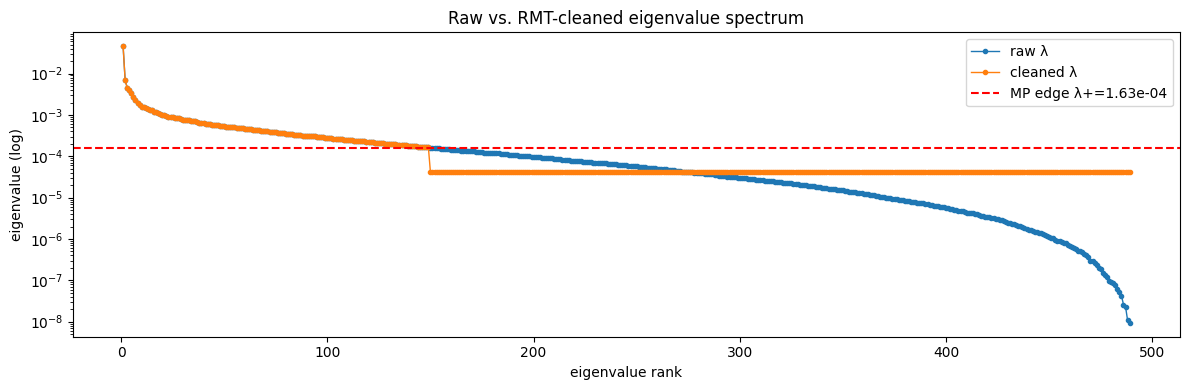

In [5]:
def rmt_clean_covariance(evals_, evecs_, mp_upper_):
    """Replace noise eigenvalues with their mean, reconstruct symmetric PSD cov.

    Uses only positive noise eigenvalues to estimate the noise mean — handles the
    q > 1 case where some noise eigenvalues are numerically zero/negative due to
    rank deficiency. The fill value floors all noise eigenvalues at a strictly
    positive number, guaranteeing the reconstructed cov is positive definite.
    """
    e = evals_.copy()
    signal_mask = e > mp_upper_
    noise_mask = ~signal_mask
    if noise_mask.sum() > 0:
        positive_noise = e[noise_mask & (e > 0)]
        if len(positive_noise) > 0:
            noise_mean = positive_noise.mean()
        elif signal_mask.sum() > 0:
            noise_mean = e[signal_mask].min()
        else:
            noise_mean = max(mp_upper_, 1e-15)
        e[noise_mask] = noise_mean
    cleaned = evecs_ @ np.diag(e) @ evecs_.T
    cleaned = (cleaned + cleaned.T) / 2.0
    return cleaned, e


cov_cleaned, evals_cleaned = rmt_clean_covariance(evals, evecs, mp_upper)

cond_raw = evals[0] / evals[-1] if evals[-1] > 0 else np.inf
cond_cleaned = evals_cleaned.max() / evals_cleaned.min()
trace_raw = evals.sum()
trace_cleaned = evals_cleaned.sum()

print(f"Signal eigs kept:                  {(evals > mp_upper).sum()} of {p}")
print(f"Noise eigs replaced with mean:     {evals[(evals <= mp_upper) & (evals > 0)].mean():.4e}")
print(f"Trace (raw):                       {trace_raw:.6e}")
print(f"Trace (cleaned):                   {trace_cleaned:.6e}    (preserved by construction)")
print(f"Condition number (raw):            {cond_raw:.2e}")
print(f"Condition number (cleaned):        {cond_cleaned:.2e}    (~{cond_raw / cond_cleaned:.0f}× better)")

fig, ax = plt.subplots(figsize=(12, 4))
rank = np.arange(1, p + 1)
ax.plot(rank, evals, label="raw λ", marker=".", linewidth=1)
ax.plot(rank, evals_cleaned, label="cleaned λ", marker=".", linewidth=1)
ax.axhline(mp_upper, color="red", linestyle="--", label=f"MP edge λ+={mp_upper:.2e}")
ax.set_yscale("log")
ax.set_xlabel("eigenvalue rank")
ax.set_ylabel("eigenvalue (log)")
ax.set_title("Raw vs. RMT-cleaned eigenvalue spectrum")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Global Minimum-Variance Portfolios — raw vs. cleaned cov

The closed-form GMV portfolio (no constraints, weights sum to 1) is:

$$w^\star = \frac{\Sigma^{-1} \mathbf{1}}{\mathbf{1}^\top \Sigma^{-1} \mathbf{1}}, \qquad \sigma^2_{w^\star} = \frac{1}{\mathbf{1}^\top \Sigma^{-1} \mathbf{1}}$$

We construct $w^\star$ from both $\Sigma_{\text{raw}}$ and $\Sigma_{\text{cleaned}}$ and compare:

- **Ex-ante variance** under each cov (in-sample optimum, but evaluating cross-cov is informative)
- **Gross leverage** $\sum_i |w_i|$ — high values mean the portfolio is taking large long-short bets driven by noise
- **Max single weight** — concentration risk
- **Effective number of names** = $1 / \sum w_i^2$ (analogous to participation ratio for portfolios)

The expected pattern: cleaning produces *less concentrated, less levered* weights because $\Sigma_{\text{cleaned}}^{-1}$ doesn't blow up the small noise eigenvalues.

In [ ]:
def gmv_weights(cov_):
    ones = np.ones(cov_.shape[0])
    inv_cov_ones = np.linalg.solve(cov_, ones)
    return inv_cov_ones / (ones @ inv_cov_ones)


w_raw = gmv_weights(cov)
w_cleaned = gmv_weights(cov_cleaned)


def portfolio_metrics(w, label, cov_self, cov_other, other_label):
    return {
        "portfolio": label,
        f"variance under {label} cov": float(w @ cov_self @ w),
        f"variance under {other_label} cov": float(w @ cov_other @ w),
        "gross leverage Σ|w|": float(np.abs(w).sum()),
        "max |w|": float(np.abs(w).max()),
        "effective # names 1/Σw²": float(1.0 / (w**2).sum()),
        "# negative weights": int((w < 0).sum()),
    }


m_raw = portfolio_metrics(w_raw, "raw", cov, cov_cleaned, "cleaned")
m_cleaned = portfolio_metrics(w_cleaned, "cleaned", cov_cleaned, cov, "raw")

# Pretty-print side by side
keys = list(m_raw.keys())
for k in keys:
    if k == "portfolio":
        print(f"{'metric':<32} {'GMV(raw)':>16} {'GMV(cleaned)':>16}")
        print("-" * 66)
        continue
    # The cross-cov keys differ between m_raw / m_cleaned; align by ordinal
    pass


# Build a parallel printout
def fmt(v):
    if isinstance(v, float):
        return f"{v:.4e}" if abs(v) < 0.01 or abs(v) > 1e3 else f"{v:.4f}"
    return str(v)


labels_and_keys = [
    ("ex-ante variance (own cov)", "variance under raw cov", "variance under cleaned cov"),
    ("ex-ante variance (other cov)", "variance under cleaned cov", "variance under raw cov"),
    ("gross leverage Σ|w|", "gross leverage Σ|w|", "gross leverage Σ|w|"),
    ("max |w|", "max |w|", "max |w|"),
    ("effective # names", "effective # names 1/Σw²", "effective # names 1/Σw²"),
    ("# negative weights", "# negative weights", "# negative weights"),
]
print(f"{'metric':<32} {'GMV(raw)':>16} {'GMV(cleaned)':>16}")
print("-" * 66)
for label, k_r, k_c in labels_and_keys:
    print(f"{label:<32} {fmt(m_raw[k_r]):>16} {fmt(m_cleaned[k_c]):>16}")

print()
print("Interpretation:")
print(f"  - GMV(raw)  in-sample variance is lower than GMV(cleaned) in-sample by construction,")
print(f"    but that's the variance of an over-fit portfolio. The cross-cov columns are the")
print(f"    informative ones: GMV(cleaned) evaluated under Σ_raw is the honest answer.")
print(f"  - Gross leverage drops by {m_raw['gross leverage Σ|w|'] / m_cleaned['gross leverage Σ|w|']:.1f}x after cleaning")
print(f"    — the raw inverse blows up small eigs, producing extreme long-short weights.")

metric                                   GMV(raw)     GMV(cleaned)
------------------------------------------------------------------
metric                                   GMV(raw)     GMV(cleaned)
------------------------------------------------------------------
ex-ante variance (own cov)             3.8243e-07       7.9909e-06
ex-ante variance (other cov)           7.5382e-04       9.1018e-06
gross leverage Σ|w|                       68.2954           6.4780
max |w|                                    0.8459           0.0645
effective # names                          0.0548           7.2481
# negative weights                            237              222

Interpretation:
  - GMV(raw)  in-sample variance is lower than GMV(cleaned) in-sample by construction,
    but that's the variance of an over-fit portfolio. The cross-cov columns are the
    informative ones: GMV(cleaned) evaluated under Σ_raw is the honest answer.
  - Gross leverage drops by 10.5x after cleaning
    — the raw 

## 6. Eigenportfolios — PC1 through PC5 as portfolios (ported from `SP500MarketStructure.py`)

L1-normalize each eigenvector to make the absolute weights sum to 1 — gives a directly comparable "factor portfolio." Then look at the heaviest long and short positions per component to assign an economic identity.

In [7]:
def eigenportfolio(evec, normalize="l1"):
    v = evec.copy()
    if normalize == "l1":
        denom = np.abs(v).sum()
    elif normalize == "l2":
        denom = np.linalg.norm(v)
    elif normalize == "sum1":
        denom = v.sum()
    elif normalize is None:
        denom = 1.0
    else:
        raise ValueError(normalize)
    return v / denom if denom != 0 else v


N_PCS = 5
eigenport_weights = np.column_stack([eigenportfolio(evecs[:, i], "l1") for i in range(N_PCS)])
eigenport_df = pd.DataFrame(
    eigenport_weights,
    index=returns_win.columns,
    columns=[f"PC{i+1}" for i in range(N_PCS)],
)
eigenport_df["company"] = [col_to_company.get(c, "?") for c in eigenport_df.index]

# Show top-5 long and top-5 short per component
print("Top 5 long and top 5 short positions per eigenportfolio:\n")
for i in range(N_PCS):
    pc = f"PC{i+1}"
    series = eigenport_df[pc]
    top_long = series.nlargest(5)
    top_short = series.nsmallest(5)
    print(f"=== {pc}  (variance share = {evals[i] / evals.sum():.1%}, sign of net weight: {'+' if series.sum() > 0 else '-'}) ===")
    print("  LONG:")
    for tic, w in top_long.items():
        print(f"    {tic:<12} {w:+.4f}   {col_to_company.get(tic, '?')}")
    print("  SHORT:")
    for tic, w in top_short.items():
        print(f"    {tic:<12} {w:+.4f}   {col_to_company.get(tic, '?')}")
    print()

Top 5 long and top 5 short positions per eigenportfolio:

=== PC1  (variance share = 30.1%, sign of net weight: -) ===
  LONG:
    AEP          -0.0000   AMERICAN ELECTRIC POWER CO INC
    WEC          -0.0001   W E C ENERGY GROUP INC
    CMS          -0.0001   C M S ENERGY CORP
    XEL          -0.0001   X C E L ENERGY INC
    DUK          -0.0001   DUKE ENERGY CORP NEW
  SHORT:
    AMD          -0.0047   ADVANCED MICRO DEVICES INC
    NVDA         -0.0045   NVIDIA CORP
    URI          -0.0044   UNITED RENTALS INC
    MU           -0.0044   MICRON TECHNOLOGY INC
    IPGP         -0.0040   I P G PHOTONICS CORP

=== PC2  (variance share = 4.5%, sign of net weight: +) ===
  LONG:
    WELL         +0.0056   WELLTOWER INC
    VTR          +0.0055   VENTAS INC
    AMT          +0.0050   AMERICAN TOWER CORP NEW
    O            +0.0049   REALTY INCOME CORP
    SBAC         +0.0049   S B A COMMUNICATIONS CORP NEW
  SHORT:
    APA          -0.0068   A P A CORP
    XEC          -0.0065   CIMAR

## 7. Cumulative Returns of PC1-PC5

Compute the daily return of each eigenportfolio over the window and accumulate. The shape of each curve is the strongest signal of what the component "is":

- PC1 should track the broad market — steadily up over 2018-19 (with the Q4-2018 drawdown).
- PC2-PC5 are long-short by construction. If a curve looks like *(growth − value)* or *(tech − defensive)* over this window, that's the factor identity.

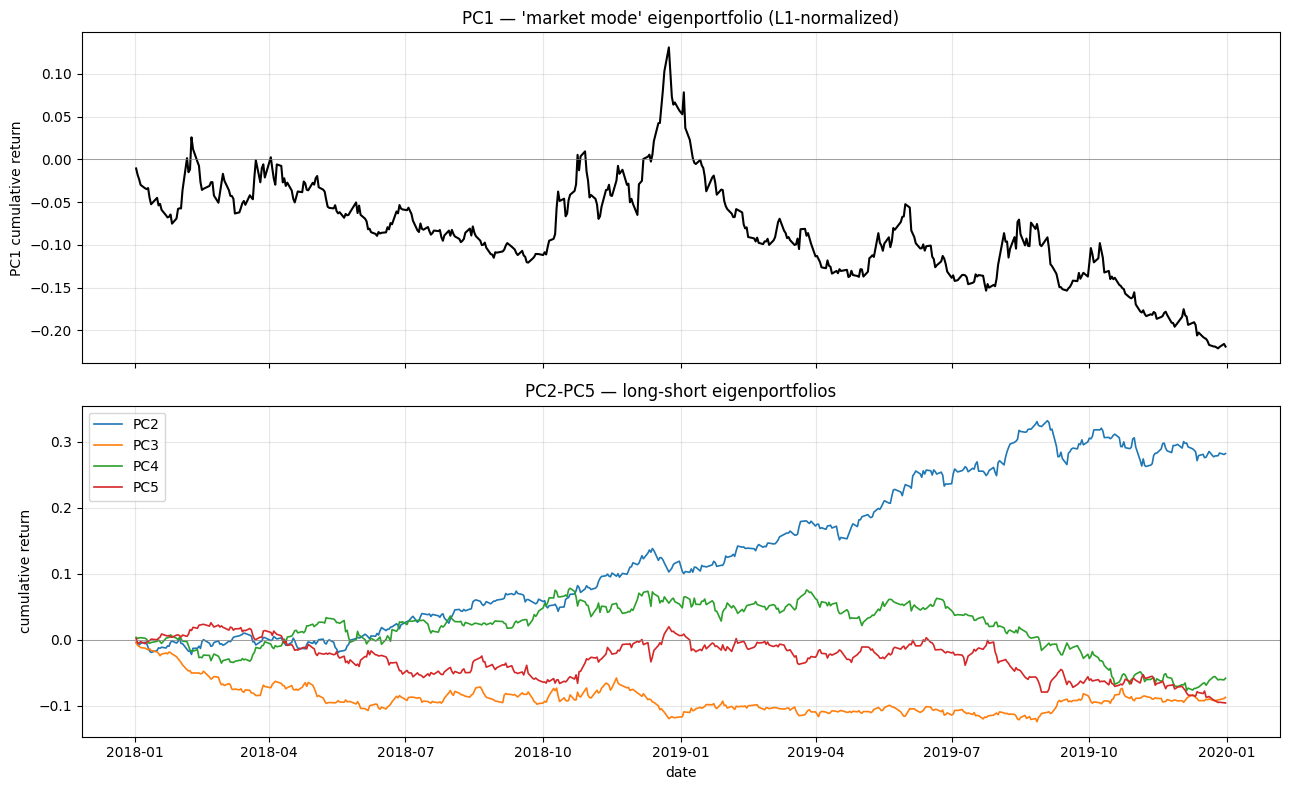


Annualized stats per eigenportfolio (window = 2018-2019):

     ann_return  ann_vol  sharpe  var_share
PC1     -0.1098   0.1672 -0.6565     0.3014
PC2      0.1271   0.0726  1.7498     0.0446
PC3     -0.0439   0.0616 -0.7126     0.0299
PC4     -0.0267   0.0822 -0.3251     0.0255
PC5     -0.0474   0.0777 -0.6108     0.0226


In [ ]:
# Apply L1-normalized weights to returns. eigenport_weights is (p, N_PCS).
daily_returns = X_raw @ eigenport_weights  # (n, N_PCS)
cum_returns = np.cumprod(1 + daily_returns, axis=0) - 1
cum_df = pd.DataFrame(cum_returns, index=returns_win.index, columns=[f"PC{i+1}" for i in range(N_PCS)])

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# PC1 alone — has very different scale than the long-short factors
axes[0].plot(cum_df.index, cum_df["PC1"], color="black", linewidth=1.5)
axes[0].axhline(0, color="gray", linewidth=0.5)
axes[0].set_ylabel("PC1 cumulative return")
axes[0].set_title("PC1 — 'market mode' eigenportfolio (L1-normalized)")
axes[0].grid(alpha=0.3)

# PC2-PC5 together
for col in ["PC2", "PC3", "PC4", "PC5"]:
    axes[1].plot(cum_df.index, cum_df[col], label=col, linewidth=1.2)
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].set_ylabel("cumulative return")
axes[1].set_xlabel("date")
axes[1].set_title("PC2-PC5 — long-short eigenportfolios")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary stats
ann_factor = 252
print("\nAnnualized stats per eigenportfolio (window = 2018-2019):\n")
stats = pd.DataFrame(
    {
        "ann_return": daily_returns.mean(axis=0) * ann_factor,
        "ann_vol": daily_returns.std(axis=0) * np.sqrt(ann_factor),
        "sharpe": (daily_returns.mean(axis=0) / daily_returns.std(axis=0)) * np.sqrt(ann_factor),
        "var_share": [evals[i] / evals.sum() for i in range(N_PCS)],
    },
    index=[f"PC{i+1}" for i in range(N_PCS)],
)
print(stats.to_string(float_format=lambda x: f"{x:.4f}"))

## 8. Rolling Track — does cleaning matter more during crises?

For each rolling **504-day** (2-year) window, build raw + cleaned cov, derive GMV portfolios from each, and track three diagnostics through time:

1. **Condition-number ratio** $\kappa(\Sigma_{\text{raw}}) / \kappa(\Sigma_{\text{cleaned}})$ — how much cleaning regularizes the inverse.
2. **Gross-leverage ratio** $\Sigma|w_{\text{raw}}| / \Sigma|w_{\text{cleaned}}|$ — by how much cleaning tames the long-short noise bets.
3. **Top-eig variance share** — regime indicator (carried over from v1).

Note: a **2-year window** keeps $q = p/n < 1$ for the full S&P universe so MP is well-posed and $\Sigma_{\text{raw}}$ is invertible. (A 1-year window with ~480 assets gives $q \approx 1.9$; the cov is rank-deficient, raw GMV is undefined, and cleaning becomes mandatory rather than diagnostic.) The trade-off: 2-year windows smooth across regime changes, so crisis spikes are softer than in v1's 1-year rolling chart.

The hypothesis: cleaning's *value* spikes during crises because the noise bulk gets noisier, so the inverse blows up more violently. Watch diagnostics 1 and 2 around 2008-Q4 and 2020-Q1.

In [ ]:
WIN_DAYS = 504  # ~2 trading years — keeps q = p/n < 1 so MP and matrix inversion are well-posed
STEP_DAYS = 63
records_v2 = []
dates = returns_full.index

for start_idx in range(0, len(dates) - WIN_DAYS + 1, STEP_DAYS):
    end_idx = start_idx + WIN_DAYS
    end_date = dates[end_idx - 1]
    members_w = members_as_of(end_date)
    cols_w = members_to_columns(members_w)
    win = returns_full.iloc[start_idx:end_idx][cols_w].dropna(axis=1, how="any")
    n_w, p_w = win.shape
    if p_w < 20 or p_w >= n_w:
        continue

    Xw = win.to_numpy(dtype=float)
    Xw = Xw - Xw.mean(axis=0, keepdims=True)
    cov_w = (Xw.T @ Xw) / (n_w - 1)
    ev_w, vec_w = eigh(cov_w)
    ev_w = ev_w[::-1]
    vec_w = vec_w[:, ::-1]
    q_w = p_w / n_w

    s2_w = iter_sigma2(ev_w, q_w)
    edge_w = s2_w * (1 + np.sqrt(q_w)) ** 2
    cov_clean_w, ev_clean_w = rmt_clean_covariance(ev_w, vec_w, edge_w)

    try:
        w_r = gmv_weights(cov_w)
        w_c = gmv_weights(cov_clean_w)
        gross_r = float(np.abs(w_r).sum())
        gross_c = float(np.abs(w_c).sum())
    except np.linalg.LinAlgError:
        gross_r = gross_c = np.nan

    pos_raw = ev_w[ev_w > 0]
    cond_raw_w = float(pos_raw.max() / pos_raw.min()) if len(pos_raw) > 0 else np.nan
    cond_cleaned_w = float(ev_clean_w.max() / ev_clean_w.min())

    records_v2.append(
        {
            "window_end": end_date,
            "n_assets": p_w,
            "q": q_w,
            "rmt_dim": int((ev_w > edge_w).sum()),
            "top_eig_share": ev_w[0] / ev_w.sum(),
            "cond_raw": cond_raw_w,
            "cond_cleaned": cond_cleaned_w,
            "gross_raw": gross_r,
            "gross_cleaned": gross_c,
        }
    )

rolling_v2 = pd.DataFrame(records_v2).set_index("window_end")
rolling_v2["cond_ratio"] = rolling_v2["cond_raw"] / rolling_v2["cond_cleaned"]
rolling_v2["gross_ratio"] = rolling_v2["gross_raw"] / rolling_v2["gross_cleaned"]
print(f"Computed {len(rolling_v2)} rolling windows ({WIN_DAYS}-day window).")
print(f"q range across windows: [{rolling_v2['q'].min():.3f}, {rolling_v2['q'].max():.3f}]")
rolling_v2[["n_assets", "q", "rmt_dim", "top_eig_share", "cond_ratio", "gross_ratio"]].head()

Computed 86 rolling windows (504-day window).
q range across windows: [0.935, 0.996]


,n_assets,q,rmt_dim,top_eig_share,cond_ratio,gross_ratio
window_end,,,,,,
2002-01-07,472,0.9365,139,0.2453,620.6438,5.3872
2002-04-09,474,0.9405,155,0.2663,664.0463,5.8157
2002-07-09,478,0.9484,154,0.2722,649.0970,5.2271
2002-10-07,478,0.9484,162,0.2840,605.1685,5.1074
2003-01-07,481,0.9544,162,0.2963,1393.5763,5.5442


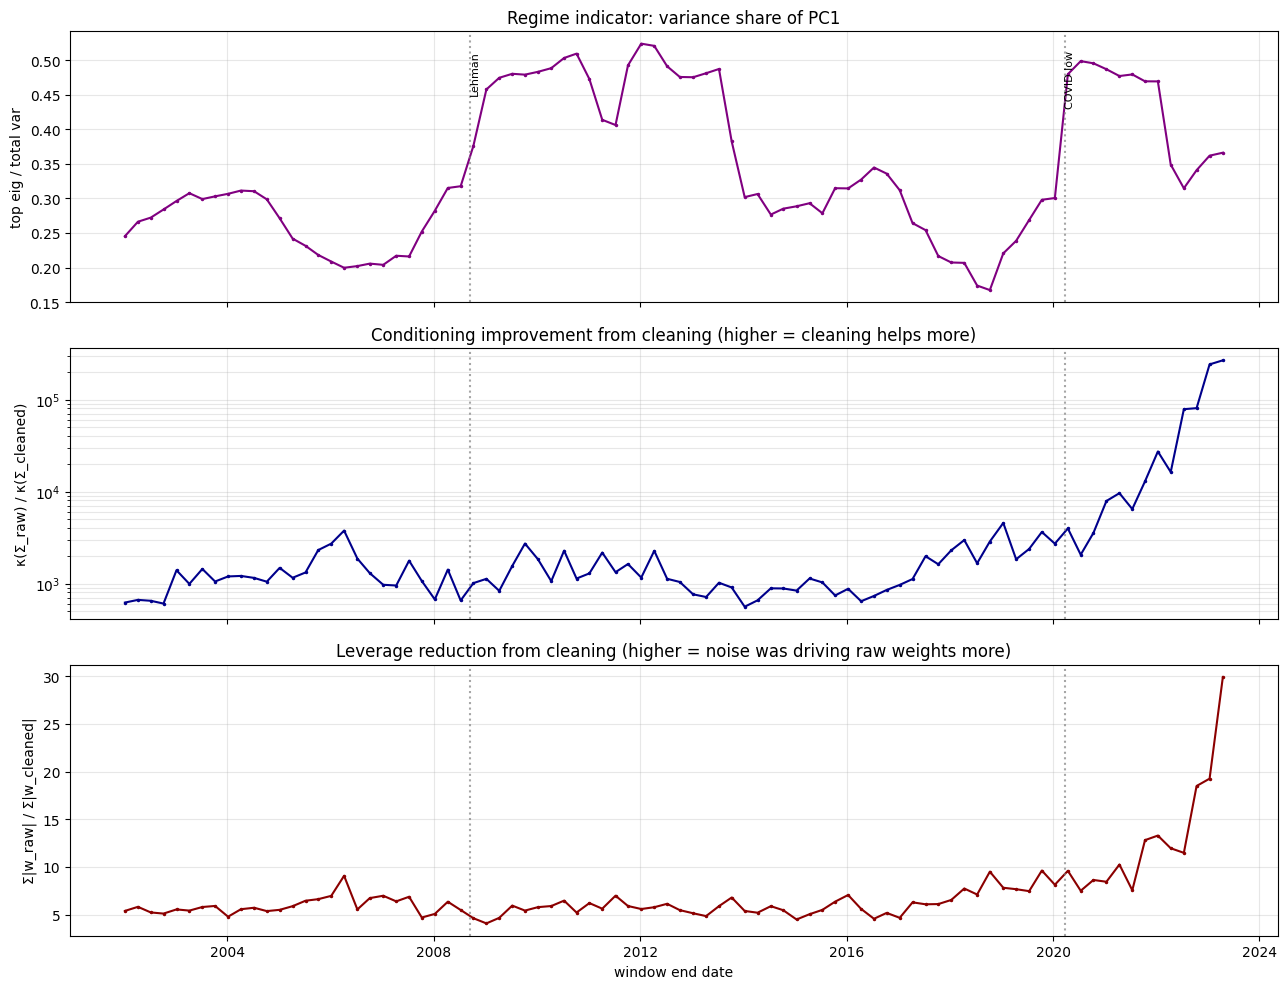

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

axes[0].plot(rolling_v2.index, rolling_v2["top_eig_share"], color="purple", marker=".", markersize=3)
axes[0].set_ylabel("top eig / total var")
axes[0].set_title("Regime indicator: variance share of PC1")
axes[0].grid(alpha=0.3)

axes[1].plot(rolling_v2.index, rolling_v2["cond_ratio"], color="darkblue", marker=".", markersize=3)
axes[1].set_yscale("log")
axes[1].set_ylabel("κ(Σ_raw) / κ(Σ_cleaned)")
axes[1].set_title("Conditioning improvement from cleaning (higher = cleaning helps more)")
axes[1].grid(alpha=0.3, which="both")

axes[2].plot(rolling_v2.index, rolling_v2["gross_ratio"], color="darkred", marker=".", markersize=3)
axes[2].set_ylabel("Σ|w_raw| / Σ|w_cleaned|")
axes[2].set_xlabel("window end date")
axes[2].set_title("Leverage reduction from cleaning (higher = noise was driving raw weights more)")
axes[2].grid(alpha=0.3)

for date_str, label in [("2008-09-15", "Lehman"), ("2020-03-23", "COVID low")]:
    d = pd.Timestamp(date_str)
    if rolling_v2.index.min() <= d <= rolling_v2.index.max():
        for ax in axes:
            ax.axvline(d, color="gray", linestyle=":", alpha=0.7)
        axes[0].text(d, axes[0].get_ylim()[1] * 0.95, label, rotation=90, va="top", fontsize=8)

plt.tight_layout()
plt.show()

## 9. Summary

What v2 added on top of v1:

| Borrowed from .py | New analysis on top |
|---|---|
| `rmt_clean_covariance` | Spectrum + condition-number comparison; rolling track of cleaning benefit |
| `eigenportfolio` (L1) | Top-long/top-short tables for PC1-PC5; cumulative-return chart; annualized stats |
| (also wired in:) GMV portfolio | Variance / leverage / concentration comparison; rolling leverage-ratio |

The deliverable upgrade: v1 estimates dimensionality, v2 turns that estimate into a denoised covariance matrix and a set of factor portfolios — the things a portfolio manager actually uses.

What to look for in the rolling chart (Section 8): the **gross-leverage ratio** is the cleanest "value of cleaning" indicator. If it spikes at Lehman / COVID, that confirms the proposal's intuition that crisis regimes are where naive sample-covariance methods fail hardest and RMT cleaning earns its keep.